
## (33, 'o_hm_rt') model for PDF shaping (n samples)

This uses the new object oriented class for PDF shaping.

* (33, 'o_hm_rt') ...... i_h2i_rate, i_h2_temp, i_ng_rate, i_ng_temp, i_pci_rate, i_wpi_rate, i_sgi_rate, i_sgi_COH2ratio, i_sgi_ReProRatio, i_o2_volfract, i_hbtemp, i_wind_rt, i_blast_H2O, i_bdn_H2O

## Web applicationi inputs and 1 outputs

Run interactively on the web at: https://rcalix1.github.io/ProbabilityDensityFunctionsFromNeuralNets/experiments/2023/july2023/XGBoost/deployment/tuyere/




## Inputs


(2, 'i_h2i_rate').........i_h2i_rate

(3, 'i_pci_rate').........i_pci_rate

(4, 'i_wpi_rate').........i_wpi_rate

(5, 'i_ngi_rate').........i_ng_rate

(6, 'i_o2_volfract').......i_o2_volfract

(7, 'i_ng_temp')...........i_ng_temp

(8, 'i_h2_temp')...........i_h2_temp

(9, 'i_hbtemp')............i_hbtemp

(10, 'i_wind_rt')..........i_wind_rt

(11, 'i_blastH2O').........i_blast_H2O

(12, 'i_BdnH2O')............i_bdn_H2O

(13, 'i_sgi_rate').........i_sgi_rate

(15, 'i_sgi_COH2ratio').....i_sgi_COH2ratio

(16, 'i_sgi_ReProRatio')....i_sgi_ReProRatio


  

## Outputs


(33, 'o_hm_rt')





## Installs


In [1]:

## !pip install xgboost
## !pip install onnxmltools
## !pip install onnxruntime



## Imports


In [2]:

import torch
import numpy as np
import pandas as pd
import sklearn
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
import math
import seaborn as sns
import random
import functorch


import torch.optim as optim


from numpy.random import normal
from scipy.stats import norm
import scipy.stats as stats
from numpy import hstack
from numpy import vstack
from numpy import exp
from sklearn.neighbors import KernelDensity

##from typing import Optional

from torch import Tensor


from torch.utils.data import TensorDataset, DataLoader

from mlxtend.plotting import heatmap

## coefficient of determination (R**2)
from sklearn.metrics import r2_score

np.set_printoptions(suppress=True)
torch.set_printoptions(sci_mode=False)




In [5]:

import xgboost as xgb
from xgboost import XGBClassifier, XGBRegressor, DMatrix, train as train_xgb
from sklearn.datasets import load_boston
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import onnxmltools
from onnxmltools.convert.xgboost.operator_converters.XGBoost import (
    convert_xgboost)
from onnxmltools.convert import convert_xgboost as convert_xgboost_booster


from zipfile import ZipFile
from skl2onnx.common.data_types import FloatTensorType
from skl2onnx import convert_sklearn, to_onnx, update_registered_converter
from skl2onnx.common.shape_calculator import (
    calculate_linear_classifier_output_shapes,
    calculate_linear_regressor_output_shapes)


# Import the ONNX runtime environment
import onnxruntime as rt



In [6]:

import PDFshapingUtils as PDF_tk



## Instantiate PDF shaping and regression class


In [7]:

PDFshapingOBJ = PDF_tk.PDFshapingUtils()



## Initialize parameters


In [8]:

PDFshapingOBJ.N_error_range = 5         ## 20
PDFshapingOBJ.mean_impulse  = 0.0       ## -7.0      ## 0.0
PDFshapingOBJ.std_impulse   = 0.001     ## 1.0
PDFshapingOBJ.kde_std       = 0.5       ## 0.1       ## 0.5      ## 3.0  ## smaller is better approximation?
PDFshapingOBJ.bandwidth     = 0.2       ## 0.2->more jagged, 2.0->more smooth


In [9]:

PDFshapingOBJ.initializeImpulseGaussian()



## Run checks


In [10]:

## print(PDFshapingOBJ.x_range_impulse_func )
## print(PDFshapingOBJ.impulse_func_vector_vals )
## print(PDFshapingOBJ.quadratic_weights)
print(PDFshapingOBJ.x_range_impulse_func.shape )
print(PDFshapingOBJ.impulse_func_vector_vals.shape )
print(PDFshapingOBJ.quadratic_weights.shape)
 
print( sum(PDFshapingOBJ.impulse_func_vector_vals) )      ## should add up to 100 (i.e. 1.0 prob density)


torch.Size([1000])
torch.Size([1000])
torch.Size([1000])
tensor(100.0000)


In [11]:

## plt.plot(PDFshapingOBJ.x_range_impulse_func, PDFshapingOBJ.impulse_func_vector_vals)
## plt.show()



## RUN KDE test


In [12]:

## PDFshapingOBJ.test_torchKDE_with_fake_data()



## Load Data


In [13]:

PDFshapingOBJ.read_csv_file_with_pandas('CFD.16.2025.csv')


In [14]:

PDFshapingOBJ.CFD_raw_data


,index,case name,i_h2i_rate,i_pci_rate,i_wpi_rate,i_ngi_rate,i_o2_volfract,i_ng_temp,i_h2_temp,i_hbtemp,...,o_h2o_sollos,o_feo_sollos,o_hm_rt,o_mw_rt,o_wf_rt,o_hm_h2share,o_mw_h2share,o_wf_h2share,o_prod_rt,o_fta
0,1,H2-0_PCI-0_WPI-0_NG-120_O2-21_NGT-300_H2T-0_HB...,0,0,0,120,21,300,0,1200,...,20.0,44.9,122.0,264.0,687.0,31.6,26.7,63.5,4050.0,1800.0
1,2,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,0,1200,...,18.5,52.6,122.0,265.0,684.0,27.9,23.4,60.6,4060.0,1850.0
2,3,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,0,1200,...,19.6,50.9,123.0,266.0,690.0,27.7,23.5,60.8,4080.0,1850.0
3,4,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,0,1200,...,19.2,52.2,124.0,268.0,690.0,27.7,23.2,60.6,4090.0,1850.0
4,5,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,0,1200,...,19.2,52.4,124.0,268.0,695.0,27.7,23.2,60.7,4110.0,1850.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4994,4995,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1600,...,18.7,40.3,353.0,763.0,2190.0,34.0,20.5,56.7,11700.0,2380.0
4995,4996,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1480,...,18.7,40.7,353.0,763.0,2190.0,33.8,20.4,56.8,11700.0,2310.0
4996,4997,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1600,...,19.2,37.5,353.0,763.0,2230.0,33.6,20.4,57.1,11700.0,2380.0
4997,4998,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1480,...,17.6,39.8,355.0,768.0,2220.0,34.0,20.0,55.7,11800.0,2310.0


In [15]:

PDFshapingOBJ.print_headers_list()


['index', 'case name', 'i_h2i_rate', 'i_pci_rate', 'i_wpi_rate', 'i_ngi_rate', 'i_o2_volfract', 'i_ng_temp', 'i_h2_temp', 'i_hbtemp', 'i_wind_rt', 'i_blastH2O', 'i_BdnH2O', 'i_sgi_rate', 'i_sgtemp', 'i_sgi_H2COratio', 'i_sgi_ReProRatio', 'o_tuy_velo', 'o_tuy_temp', 'o_burn', 'o_delp', 'o_co_vf', 'o_co2_vf', 'o_h2_vf', 'o_n2_vf', 'o_co_util', 'o_h2_util', 'o_tgt', 'o_coke_rt', 'o_hmt', 'o_co2_sollos', 'o_h2o_sollos', 'o_feo_sollos', 'o_hm_rt', 'o_mw_rt', 'o_wf_rt', 'o_hm_h2share', 'o_mw_h2share', 'o_wf_h2share', 'o_prod_rt', 'o_fta']
41
(0, 'index')
(1, 'case name')
(2, 'i_h2i_rate')
(3, 'i_pci_rate')
(4, 'i_wpi_rate')
(5, 'i_ngi_rate')
(6, 'i_o2_volfract')
(7, 'i_ng_temp')
(8, 'i_h2_temp')
(9, 'i_hbtemp')
(10, 'i_wind_rt')
(11, 'i_blastH2O')
(12, 'i_BdnH2O')
(13, 'i_sgi_rate')
(14, 'i_sgtemp')
(15, 'i_sgi_H2COratio')
(16, 'i_sgi_ReProRatio')
(17, 'o_tuy_velo')
(18, 'o_tuy_temp')
(19, 'o_burn')
(20, 'o_delp')
(21, 'o_co_vf')
(22, 'o_co2_vf')
(23, 'o_h2_vf')
(24, 'o_n2_vf')
(25, 'o_co_ut

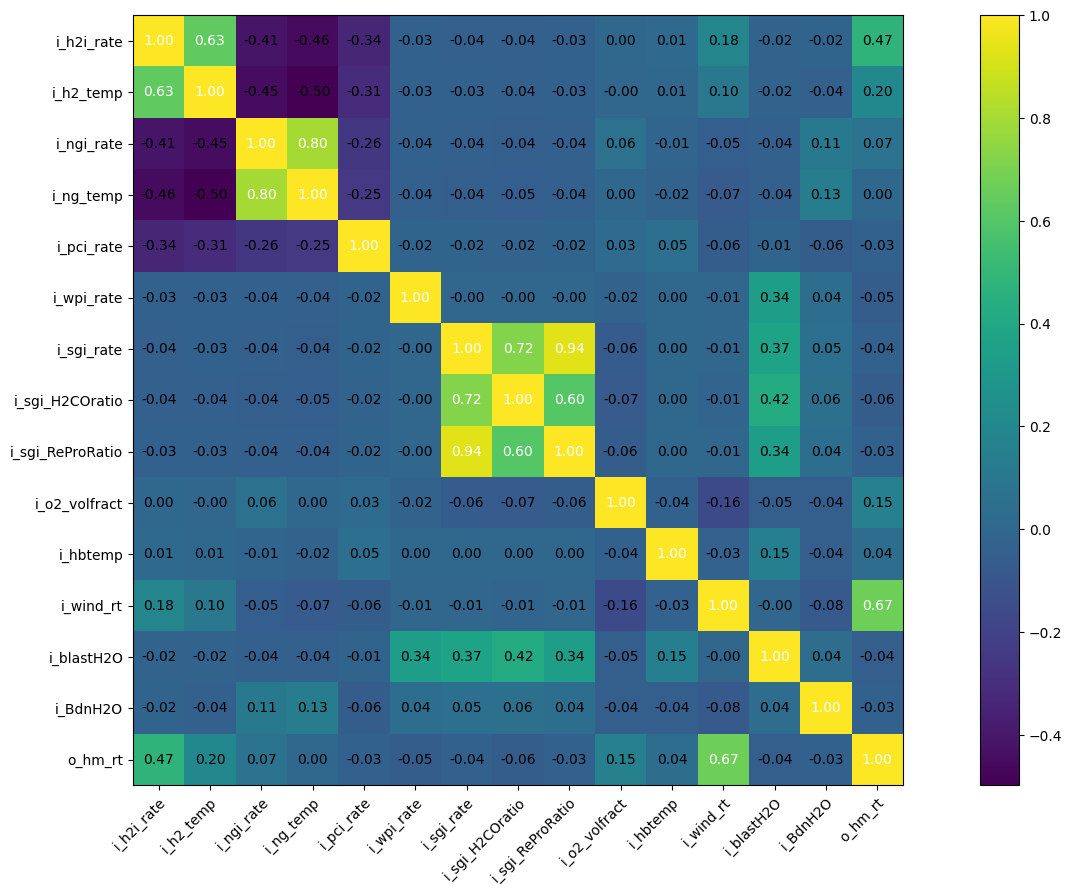

In [16]:




PDFshapingOBJ.list_of_selected_column_names = ['i_h2i_rate','i_h2_temp','i_ngi_rate','i_ng_temp','i_pci_rate',
                    'i_wpi_rate','i_sgi_rate','i_sgi_H2COratio','i_sgi_ReProRatio','i_o2_volfract',
                    'i_hbtemp','i_wind_rt','i_blastH2O','i_BdnH2O', 'o_hm_rt' ]

ONNX_name = 'o_hm_rt'


PDFshapingOBJ.print_correlation_coefficients()


In [17]:

PDFshapingOBJ.convert_pd_data_to_numpy()


[[1
  'H2-0_PCI-0_WPI-0_NG-120_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-7_SGI-0_SGT-0_SGC_0 '
  0 ... 63.5 4050.0 1800.0]
 [2
  'H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-1_SGI-0_SGT-0_SGC_0 '
  0 ... 60.6 4060.0 1850.0]
 [3
  'H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  0 ... 60.8 4080.0 1850.0]
 ...
 [4997
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1600_WR-230_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  30 ... 57.1 11700.0 2380.0]
 [4998
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1480_WR-230_MHB-5.7_BM-3_SGI-0_SGT-0_SGC_0 '
  30 ... 55.7 11800.0 2310.0]
 [4999
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1480_WR-230_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  30 ... 56.2 11800.0 2310.0]]
(4999, 41)



## Select inputs and outputs


In [18]:

PDFshapingOBJ.gen_X_y_for_selected_indeces(  
                   inputs = [ 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16 ] , 
                   outputs= [ 33 ]   
)





14
1


In [19]:

print(PDFshapingOBJ.X.shape)
print(PDFshapingOBJ.y.shape)


(4999, 14)
(4999, 1)


In [20]:

PDFshapingOBJ.random_seed = int( random.random() * 100  )         ## defautl is 42


In [21]:

PDFshapingOBJ.split_np_data_train_test(selected_test_size=0.2)


(3999, 14)
(1000, 14)
(3999, 1)
(1000, 1)


In [22]:

PDFshapingOBJ.convert_dataset_from_np_to_torch()


In [23]:

PDFshapingOBJ.standardize_X_scales()
PDFshapingOBJ.standardize_y_scales()


In [24]:

PDFshapingOBJ.gen_Dataloader_train()

PDFshapingOBJ.train_dl



## NN architectures


In [25]:

#######################################################
## Linear Regression

class LinRegNet_SIO(nn.Module):
    ## initialize the layers
    def __init__(self, x_means, x_deviations, y_means, y_deviations):
        super().__init__()
        
        self.x_means      = x_means
        self.x_deviations = x_deviations
        self.y_means      = y_means
        self.y_deviations = y_deviations
        
        self.linear1 = nn.Linear(14, 1) 
        
        ## nn.init.xavier_uniform_(self.linear1.weight)
        ## nn.init.zeros_(self.linear1.bias)

    ## perform inference
    def forward(self, x):
        x = (x - self.x_means) / self.x_deviations
        
        y_scaled = self.linear1(x)
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        return y_descaled, y_scaled

    
#############################################################
## Multi-Layer Perceptron

class MLP_Net_SIO(nn.Module):
    ## initialize the layers
    def __init__(self, x_means, x_deviations, y_means, y_deviations):
        super().__init__()
        
        self.x_means      = x_means
        self.x_deviations = x_deviations
        self.y_means      = y_means
        self.y_deviations = y_deviations
        
        self.linear1 = nn.Linear(14, 10)
        self.act1    = nn.Sigmoid()                       ## Tanh() 
        self.linear2 = nn.Linear(10, 1)
        self.dropout = nn.Dropout(0.25)
        
        ## nn.init.xavier_uniform_(self.linear1.weight)
        ## nn.init.zeros_(self.linear1.bias)
        
        ## nn.init.xavier_uniform_(self.linear2.weight)
        ## nn.init.zeros_(self.linear2.bias)
    
    ## perform inference
    def forward(self, x):
        x = (x - self.x_means) / self.x_deviations
        x = self.linear1(x)
        x = self.act1(x)
        x = self.dropout(x)
        
        y_scaled = self.linear2(x)
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        return y_descaled, y_scaled
    

#############################################################
## Deep Learning model with 2 hidden layers


class DL_Net_SIO(nn.Module):
    
    ## initialize the layers
    def __init__(self, x_means, x_deviations, y_means, y_deviations):
        super().__init__()
        
        self.x_means      = x_means
        self.x_deviations = x_deviations
        self.y_means      = y_means
        self.y_deviations = y_deviations
        
        self.linear1 = nn.Linear(14, 10)
        self.act1    = nn.Sigmoid()                       ## Tanh() 
        self.linear2 = nn.Linear(10, 6)
        self.act2    = nn.Sigmoid() 
        self.linear3 = nn.Linear(6, 1)
        self.dropout = nn.Dropout(0.25)
        
        ## nn.init.xavier_uniform_(self.linear1.weight)
        ## nn.init.zeros_(self.linear1.bias)
        
        ## nn.init.xavier_uniform_(self.linear2.weight)
        ## nn.init.zeros_(self.linear2.bias)
        
        ## nn.init.xavier_uniform_(self.linear3.weight)
        ## nn.init.zeros_(self.linear3.bias)
    
    ## perform inference
    def forward(self, x):
        
        x = (x - self.x_means) / self.x_deviations
        x = self.linear1(x)
        x = self.act1(x)
        x = self.dropout(x)
        x = self.linear2(x)
        x = self.act2(x)
        x = self.dropout(x)
        
        y_scaled = self.linear3(x)
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        return y_descaled, y_scaled


In [26]:

#############################################################
##   F1      plus       F2
## Linear     +      Nonlinear

class F1plusF2_SIO(nn.Module):
    ## initialize the layers
    def __init__(self, x_means, x_deviations, y_means, y_deviations):
        super().__init__()
        
        self.x_means      = x_means
        self.x_deviations = x_deviations
        self.y_means      = y_means
        self.y_deviations = y_deviations
        
        ## F1
        self.f1_linear1 = nn.Linear(14, 1)       
        
        ## F2
        self.f2_linear1 = nn.Linear(14, 10)
        self.f2_act1    = nn.Sigmoid()                    ## Tanh()                       
        self.f2_linear2 = nn.Linear(10, 1)       
        self.f2_dropout = nn.Dropout(0.25)
        
        
    ## perform inference
    def forward(self, x):
        x = (x - self.x_means) / self.x_deviations
        
        ## F1
        f1 = self.f1_linear1(x)
        
        ## F2
        f2 = self.f2_linear1(x)
        f2 = self.f2_act1(f2)
        f2 = self.f2_dropout(f2)
        f2 = self.f2_linear2(f2)
        
        
        y_scaled   = f1 + f2
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        return y_descaled, y_scaled
    



## Results for g(x) = F1(x) + F2(x) with No PDF shaping

F1 = Linear

F2 = Nonlinear


In [27]:

def fit_y_scaled(num_epochs, model, loss_fn, opt):
    
    PDFshapingOBJ.list_metric = []
    for epoch in range(num_epochs):
        for xb, yb in PDFshapingOBJ.train_dl:
            pred_descaled, pred_scaled = model(xb)
            loss = loss_fn(pred_scaled, yb)
            loss.backward()
            opt.step()
            opt.zero_grad()
        
        if epoch % 200 == 0:
            print(epoch, " loss= ", loss)
            
            
        pred_descaled, pred_scaled = model(PDFshapingOBJ.X_train_tr)
        r2_avg = torch.mean(
            torch.tensor(
                r2_score( pred_scaled.detach().numpy(),  PDFshapingOBJ.y_train_tr_scaled.numpy()   )
            )
        )
        PDFshapingOBJ.list_metric.append(  r2_avg.detach().numpy()  )
            
    PDFshapingOBJ.func_plot_performance()
            
    pred_descaled, pred_scaled = model(PDFshapingOBJ.X_train_tr)
    print('Training loss:', loss_fn(  pred_scaled,           PDFshapingOBJ.y_train_tr_scaled          ))
    print('Training R**2:', r2_score( pred_scaled.detach().numpy(), PDFshapingOBJ.y_train_tr_scaled.numpy()  ))
    


In [28]:

PDFshapingOBJ.the_string           = "No_PDF_shaping"
PDFshapingOBJ.furnace_model_name   = ONNX_name


0  loss=  tensor(0.5796, grad_fn=<MseLossBackward0>)
200  loss=  tensor(0.1631, grad_fn=<MseLossBackward0>)
400  loss=  tensor(0.0205, grad_fn=<MseLossBackward0>)
600  loss=  tensor(0.0754, grad_fn=<MseLossBackward0>)
800  loss=  tensor(0.0818, grad_fn=<MseLossBackward0>)
1000  loss=  tensor(0.1401, grad_fn=<MseLossBackward0>)
1200  loss=  tensor(0.0688, grad_fn=<MseLossBackward0>)
1400  loss=  tensor(0.0435, grad_fn=<MseLossBackward0>)
1600  loss=  tensor(0.1434, grad_fn=<MseLossBackward0>)
1800  loss=  tensor(0.0596, grad_fn=<MseLossBackward0>)


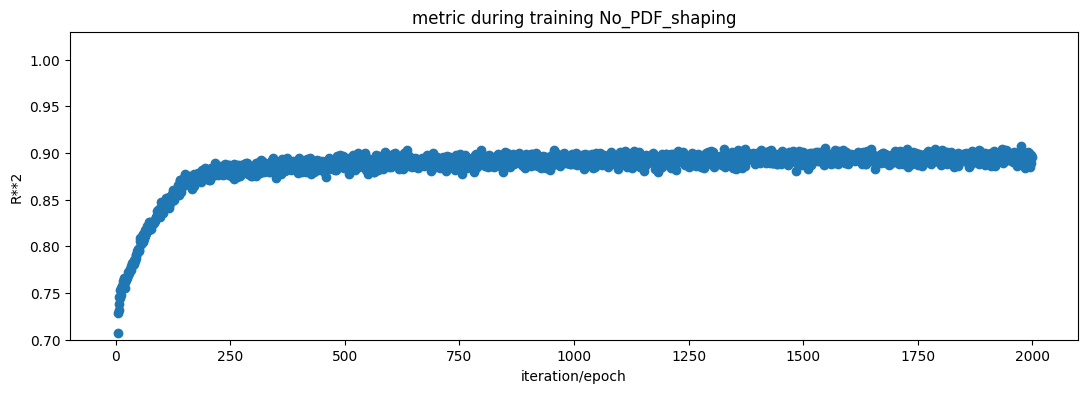

Training loss: tensor(0.1001, grad_fn=<MseLossBackward0>)
Training R**2: 0.8901370583884971
Test loss - scaled: tensor(0.0876, grad_fn=<MseLossBackward0>)
Test loss - descaled: tensor(182.7319, grad_fn=<MseLossBackward0>)
Testing R**2 - scaled: 0.9005623596705926
Testing R**2 - descaled: 0.9005623609507132
*****
*****
Testing R**2 - Output: 0 o_hm_rt 0.9005623609507132


In [29]:

model = F1plusF2_SIO(
             PDFshapingOBJ.x_means, 
             PDFshapingOBJ.x_deviations, 
             PDFshapingOBJ.y_means, 
             PDFshapingOBJ.y_deviations
)

opt = torch.optim.Adam(   model.parameters(), lr=PDFshapingOBJ.learning_rate   )
loss_fn = F.mse_loss


fit_y_scaled(PDFshapingOBJ.N_EPOCHS, model, loss_fn, opt)


pred_descaled, pred_scaled = model(PDFshapingOBJ.X_test_tr)
print('Test loss - scaled:',   loss_fn(     pred_scaled,         PDFshapingOBJ.y_test_tr_scaled          ))
print('Test loss - descaled:', loss_fn(     pred_descaled,       PDFshapingOBJ.y_test_tr                 ))
print('Testing R**2 - scaled:', r2_score( pred_scaled.detach().numpy(), PDFshapingOBJ.y_test_tr_scaled.numpy() ))
print('Testing R**2 - descaled:', r2_score( pred_descaled.detach().numpy(), PDFshapingOBJ.y_test_tr.numpy()    ))

PDFshapingOBJ.print_individual_Rsquare(pred_descaled, PDFshapingOBJ.y_test_tr)


In [30]:

list_preds = []
list_reals = []

for i in range(len(PDFshapingOBJ.X_test_tr)):
    print("**************************************************")
    print("preds, real")
    preds_descaled, preds_scaled = model(PDFshapingOBJ.X_test_tr[i])

    np_pred = preds_descaled[0].detach().numpy()              ## [0]
    np_real = PDFshapingOBJ.y_test_tr[i].detach().numpy()

    for j in range(len(np_pred)):
        print((np_pred[j], np_real[j]))
        list_preds.append(np_pred[j])
        list_reals.append(np_real[j])


**************************************************
preds, real
(257.9379, 253.0)
**************************************************
preds, real
(263.89316, 238.0)
**************************************************
preds, real
(255.68816, 251.0)
**************************************************
preds, real
(190.29503, 192.0)
**************************************************
preds, real
(217.83365, 221.0)
**************************************************
preds, real
(270.84775, 273.0)
**************************************************
preds, real
(302.4901, 301.0)
**************************************************
preds, real
(319.42892, 326.0)
**************************************************
preds, real
(265.52182, 264.0)
**************************************************
preds, real
(318.5536, 310.0)
**************************************************
preds, real
(219.49928, 211.0)
**************************************************
preds, real
(174.02759, 177.0)
*******************

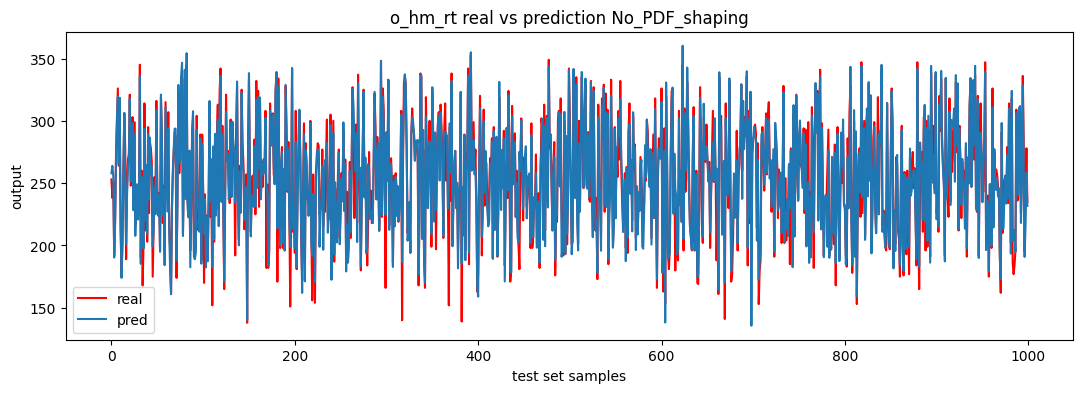

/Users/user/Desktop/CIVS_last_Phase/Forward/2025september/New5000SamplesDataset/PDFshapingUtils.py:353: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(error, bins=n_bins, color="blue")


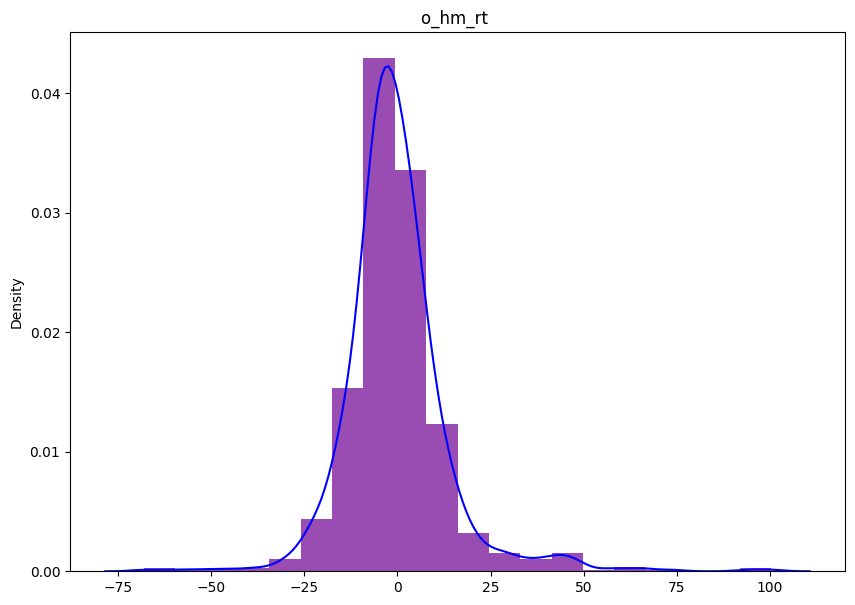

In [31]:

PDFshapingOBJ.plot_preds_vs_reals( list_preds, list_reals )


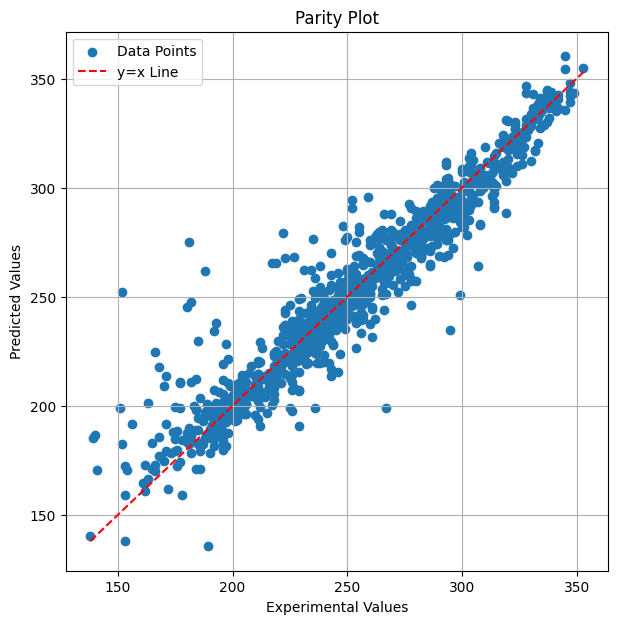

In [32]:

import matplotlib.pyplot as plt
import numpy as np

# Example data: Replace with your actual experimental and predicted values
## experimental_values = np.array([10, 20, 30, 40, 50])
## predicted_values    = np.array([11, 19, 32, 38, 51])

experimental_values = list_reals
predicted_values    = list_preds



plt.figure(figsize=(7, 7)) # Adjust figure size as needed
plt.scatter(experimental_values, predicted_values, label='Data Points')
plt.plot([min(experimental_values), max(experimental_values)],
        [min(experimental_values), max(experimental_values)],
        '--r', label='y=x Line') # Red dashed line for y=x

plt.xlabel('Experimental Values')
plt.ylabel('Predicted Values')
plt.title('Parity Plot')
plt.legend()
plt.grid(True)
plt.show()




## Export ONNX model


In [33]:


name_to_use_onnx = "ONNXmodels/F1plusF2NNs_" + ONNX_name + ".onnx"

model.eval()

dummy_input = torch.randn(1, 14)


input_names = ["input1"]
output_names = ["output1", "output2"]

torch.onnx.export(
  model, 
  dummy_input, 
  name_to_use_onnx, 
  verbose=False, 
  input_names  = input_names,
  output_names = output_names
)




## To compare NNs to XGBoost


In [34]:

##      y_pred = regressor.predict(PDFshapingOBJ.X_test )

pred_descaled, pred_scaled = model(PDFshapingOBJ.X_test_tr)


In [35]:

pred_descaled


tensor([[256.2546],
        [260.1177],
        [261.2271],
        [191.2257],
        [214.4922],
        [267.7508],
        [301.1145],
        [321.6324],
        [259.0763],
        [315.3562],
        [217.6124],
        [178.0679],
        [197.0533],
        [255.9172],
        [303.5113],
        [248.6655],
        [199.4953],
        [236.8991],
        [268.6954],
        [273.7937],
        [323.2025],
        [251.3362],
        [250.9243],
        [296.5270],
        [230.1249],
        [281.0084],
        [214.4006],
        [239.3018],
        [233.3007],
        [230.8070],
        [230.1324],
        [341.4556],
        [182.4302],
        [254.1293],
        [185.8293],
        [206.3694],
        [293.7521],
        [213.5571],
        [262.8126],
        [213.4911],
        [292.7799],
        [235.0209],
        [282.2722],
        [266.7718],
        [261.0080],
        [199.5855],
        [214.7978],
        [250.9984],
        [221.0049],
        [303.3965],


In [36]:

## r2_score( PDFshapingOBJ.y_test, y_pred )

print('Testing R**2 - scaled:', r2_score( pred_scaled.detach().numpy(), PDFshapingOBJ.y_test_tr_scaled.numpy() ))
print('Testing R**2 - descaled:', r2_score( pred_descaled.detach().numpy(), PDFshapingOBJ.y_test_tr.numpy()    ))


Testing R**2 - scaled: 0.9216912084398856
Testing R**2 - descaled: 0.9216912055488977



## Results for g(x) = F1(x) + F2(x) with PDF shaping

F1 = Linear

F2 = Nonlinear


In [37]:

def fit_y_scaled_PDF(num_epochs, num_epochs_pdf, model, loss_fn, opt, kl_loss, scheduler):
    
    PDFshapingOBJ.list_metric = []
      
    for epoch in range(num_epochs):
        for xb, yb in PDFshapingOBJ.train_dl:
            
            pred_descaled, pred_scaled = model(xb)
            loss = loss_fn(pred_scaled, yb)
            opt.zero_grad()
            loss.backward()
            opt.step()
            
            
        if epoch % 200 == 0:
            print(epoch, " loss= ", loss)
        
        pred_descaled, pred_scaled = model(PDFshapingOBJ.X_train_tr)
        r2_avg = torch.mean(torch.tensor(
                r2_score( pred_scaled.detach().numpy(),  PDFshapingOBJ.y_train_tr_scaled.numpy()  )
        ))
        PDFshapingOBJ.list_metric.append(r2_avg.detach().numpy())
        
        
    opt = torch.optim.Adam(   model.parameters(), lr=PDFshapingOBJ.learning_rate_pdfcontrol  )    
        
    for epoch in range(num_epochs_pdf):
        
        pred_descaled, pred_scaled = model(PDFshapingOBJ.X_train_tr)
       
        error =   pred_scaled.float() - PDFshapingOBJ.y_train_tr_scaled.float()          ## 715  x 1
        
        basisFunc = PDFshapingOBJ.train_multiple_kernels_per_output( error )             ## 1000 x 1
        
        p_pred = basisFunc.float() 
        q_real = PDFshapingOBJ.impulse_func_vector_vals.unsqueeze(1).float() 
        
        
        diff = ( p_pred - q_real )**2              ## 1000 x 1
        diff = diff * PDFshapingOBJ.quadratic_weights.unsqueeze(1)      
          
        
        loss = torch.mean( diff  ) 
        

        ## loss_diff = loss_fn(p_pred, q_real)
        ## input_kl  = F.log_softmax(p_pred, dim=0) # F.log_softmax(p_kl)
        ## target_kl = F.softmax(    q_real, dim=0) # F.softmax(q_kl)
        ## loss =  loss_diff   ## kl_loss(input_kl, target_kl)  ##   +  torch.std(p_pred)
        
        
        opt.zero_grad()
        loss.backward()
        opt.step()
        
      
        
        ## PDFshapingOBJ.updateImpulseGaussian_with_new_standard_deviation(decay_impulse_std )
        

        ## print(epoch, " loss= ", loss)
        if epoch % 5000 == 0:
            print(epoch, " loss= ", loss)
            print(PDFshapingOBJ.impulse_func_vector_vals.shape )
            print(PDFshapingOBJ.quadratic_weights.shape)
            print(error.shape)
            print(basisFunc.shape)
            ##### PDFshapingOBJ.print_errors_kdes(  error, basisFunc )
            print(PDFshapingOBJ.impulse_func_vector_vals.shape)
            print('Epoch-{0} lr: {1}'.format(epoch, opt.param_groups[0]['lr']))
      

        r2_avg = torch.mean(torch.tensor(
                 r2_score( pred_scaled.detach().numpy(),  PDFshapingOBJ.y_train_tr_scaled.numpy()  )
        ))
        PDFshapingOBJ.list_metric.append(  r2_avg.detach().numpy()  )
        
        
            
    PDFshapingOBJ.func_plot_performance()
            
    pred_descaled, pred_scaled = model(PDFshapingOBJ.X_train_tr)
    print('Training loss:', loss_fn(  pred_scaled,       PDFshapingOBJ.y_train_tr_scaled          ))
    print('Training R**2:', r2_score( pred_scaled.detach().numpy(), PDFshapingOBJ.y_train_tr_scaled.numpy() ))
    


In [38]:

PDFshapingOBJ.the_string           = "With_PDF_shaping"
PDFshapingOBJ.furnace_model_name   = ONNX_name

PDFshapingOBJ.learning_rate_pdfcontrol  = 0.001       ## 0.001
PDFshapingOBJ.N_EPOCHS_PDF              = 2000
PDFshapingOBJ.N_EPOCHS                  = 0

decay_impulse_std                       = PDFshapingOBJ.std_impulse / PDFshapingOBJ.N_EPOCHS_PDF 


666
0  loss=  tensor(0.0244, grad_fn=<MeanBackward0>)
torch.Size([1000])
torch.Size([1000])
torch.Size([3999, 1])
torch.Size([1000, 1])
torch.Size([1000])
Epoch-0 lr: 0.001


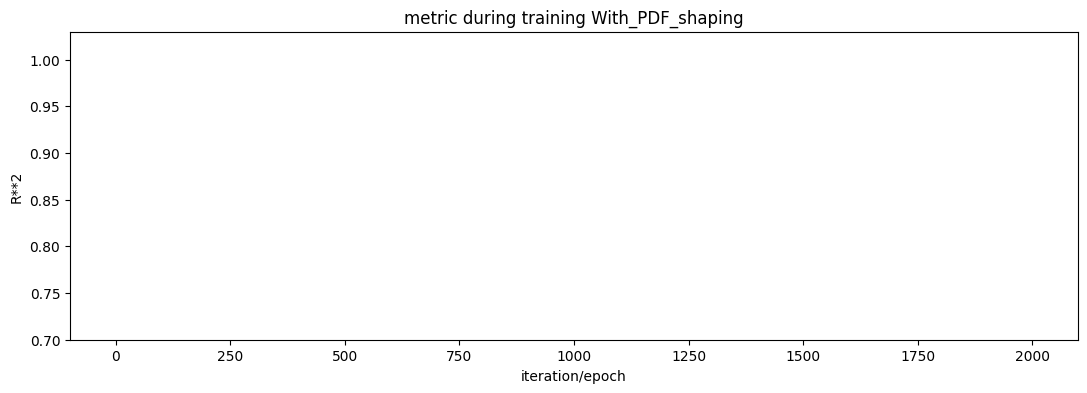

Training loss: tensor(0.7421, grad_fn=<MseLossBackward0>)
Training R**2: 0.32915969269404044
Test loss - scaled: tensor(0.5067, grad_fn=<MseLossBackward0>)
Test loss - descaled: tensor(1057.0364, grad_fn=<MseLossBackward0>)
Testing R**2 - scaled: 0.4663805417020557
Testing R**2 - descaled: 0.46638054427587816
*****
*****
Testing R**2 - Output: 0 o_hm_rt 0.46638054427587816


In [39]:

model = F1plusF2_SIO(
             PDFshapingOBJ.x_means, 
             PDFshapingOBJ.x_deviations, 
             PDFshapingOBJ.y_means, 
             PDFshapingOBJ.y_deviations
)



opt         = torch.optim.Adam(   model.parameters(), lr=PDFshapingOBJ.learning_rate_pdfcontrol    )


step_size_scheduler = int(PDFshapingOBJ.N_EPOCHS_PDF / 3)
print(step_size_scheduler)
                          
scheduler   = torch.optim.lr_scheduler.StepLR(opt, step_size=1000, gamma=0.1)



loss_fn      = F.mse_loss
kl_loss      = nn.KLDivLoss(reduction="batchmean")
loss_softmax = F.binary_cross_entropy


fit_y_scaled_PDF(PDFshapingOBJ.N_EPOCHS, PDFshapingOBJ.N_EPOCHS_PDF, model, loss_fn, opt, kl_loss, scheduler)

pred_descaled, pred_scaled = model(PDFshapingOBJ.X_test_tr)
print('Test loss - scaled:',   loss_fn(     pred_scaled,       PDFshapingOBJ.y_test_tr_scaled          ))
print('Test loss - descaled:', loss_fn(     pred_descaled,     PDFshapingOBJ.y_test_tr                 ))
print('Testing R**2 - scaled:',   r2_score( pred_scaled.detach().numpy(),PDFshapingOBJ.y_test_tr_scaled.numpy() ))
print('Testing R**2 - descaled:', r2_score( pred_descaled.detach().numpy(), PDFshapingOBJ.y_test_tr.numpy()   ))


PDFshapingOBJ.print_individual_Rsquare(pred_descaled, PDFshapingOBJ.y_test_tr)


In [40]:

list_preds = []
list_reals = []

for i in range(len(PDFshapingOBJ.X_test_tr)):
    print("**************************************************")
    print("preds, real")
    preds_descaled, preds_scaled = model(PDFshapingOBJ.X_test_tr[i])

    np_pred = preds_descaled[0].detach().numpy()              ## [0]
    np_real = PDFshapingOBJ.y_test_tr[i].detach().numpy()

    for j in range(len(np_pred)):
        print((np_pred[j], np_real[j]))
        list_preds.append(np_pred[j])
        list_reals.append(np_real[j])


**************************************************
preds, real
(256.9696, 253.0)
**************************************************
preds, real
(258.29202, 238.0)
**************************************************
preds, real
(262.5905, 251.0)
**************************************************
preds, real
(192.99101, 192.0)
**************************************************
preds, real
(221.51955, 221.0)
**************************************************
preds, real
(267.69687, 273.0)
**************************************************
preds, real
(303.25726, 301.0)
**************************************************
preds, real
(326.29547, 326.0)
**************************************************
preds, real
(264.29178, 264.0)
**************************************************
preds, real
(304.03973, 310.0)
**************************************************
preds, real
(214.17267, 211.0)
**************************************************
preds, real
(181.72473, 177.0)
******************

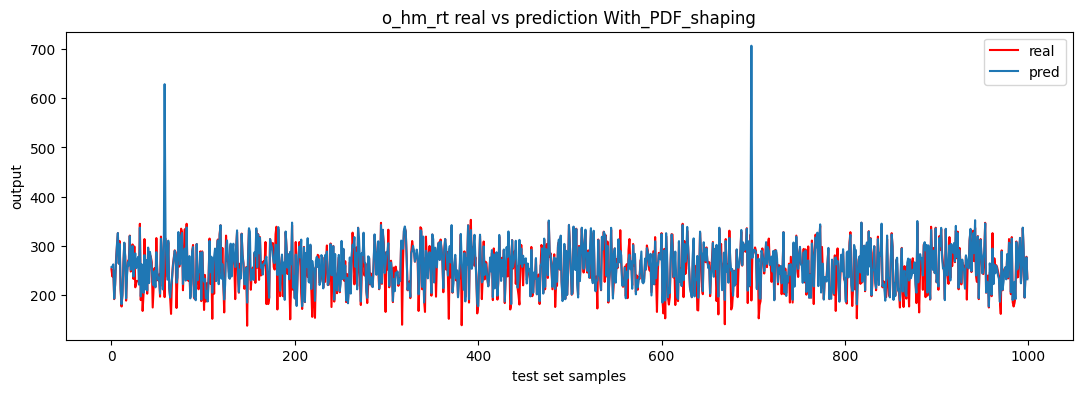

/Users/user/Desktop/CIVS_last_Phase/Forward/2025september/New5000SamplesDataset/PDFshapingUtils.py:353: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(error, bins=n_bins, color="blue")


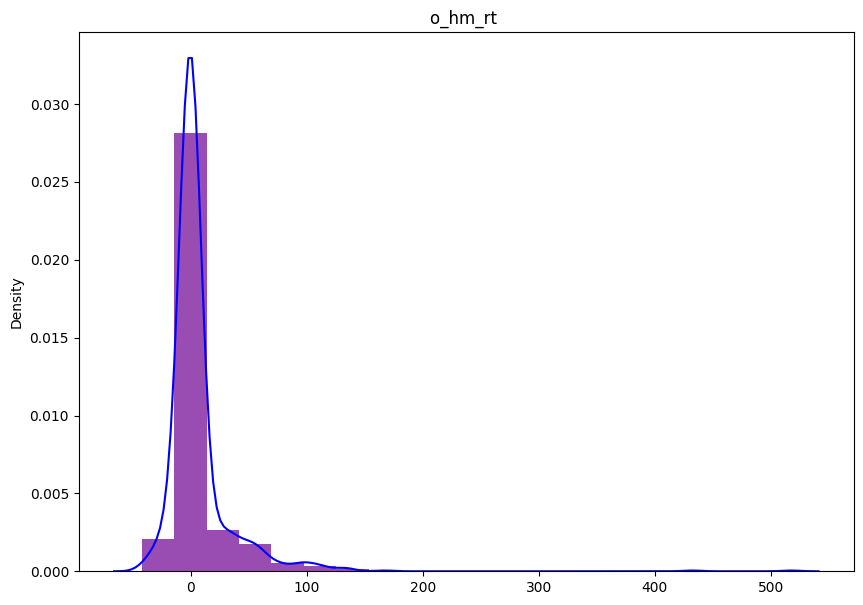

In [41]:

PDFshapingOBJ.plot_preds_vs_reals( list_preds, list_reals )


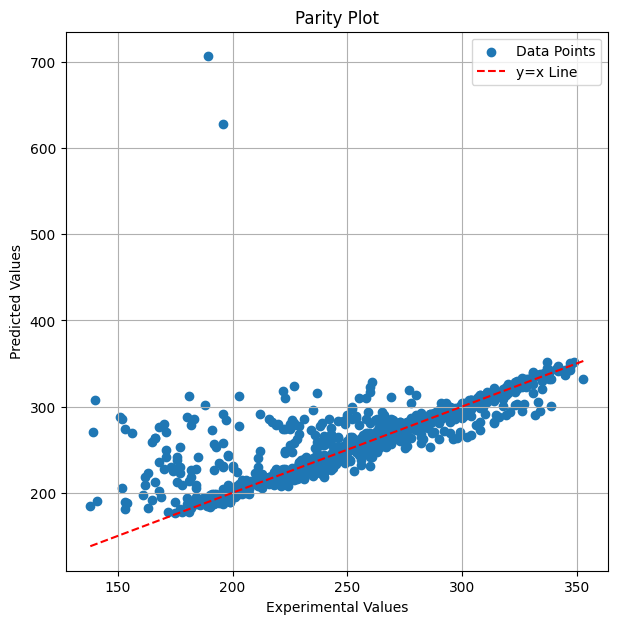

In [42]:

import matplotlib.pyplot as plt
import numpy as np

# Example data: Replace with your actual experimental and predicted values
## experimental_values = np.array([10, 20, 30, 40, 50])
## predicted_values    = np.array([11, 19, 32, 38, 51])

experimental_values = list_reals
predicted_values    = list_preds



plt.figure(figsize=(7, 7)) # Adjust figure size as needed
plt.scatter(experimental_values, predicted_values, label='Data Points')
plt.plot([min(experimental_values), max(experimental_values)],
        [min(experimental_values), max(experimental_values)],
        '--r', label='y=x Line') # Red dashed line for y=x

plt.xlabel('Experimental Values')
plt.ylabel('Predicted Values')
plt.title('Parity Plot')
plt.legend()
plt.grid(True)
plt.show()




## To compare to NNs to XGBoost


In [43]:

##      y_pred = regressor.predict(PDFshapingOBJ.X_test )

pred_descaled, pred_scaled = model(PDFshapingOBJ.X_test_tr)


In [44]:

## y_pred

pred_descaled


tensor([[257.4855],
        [258.3728],
        [262.0627],
        [198.1801],
        [223.1937],
        [267.2062],
        [303.1766],
        [294.6637],
        [257.0587],
        [301.6318],
        [210.6432],
        [181.6467],
        [199.5389],
        [259.7940],
        [307.4865],
        [280.3787],
        [188.4331],
        [215.2455],
        [267.4715],
        [271.3773],
        [321.4784],
        [252.5821],
        [251.5344],
        [274.9510],
        [234.3469],
        [266.2563],
        [257.9118],
        [283.4318],
        [270.0346],
        [278.0576],
        [226.1020],
        [335.9881],
        [190.8609],
        [261.7375],
        [235.8936],
        [192.7848],
        [282.2252],
        [215.3859],
        [272.6303],
        [212.6393],
        [295.6377],
        [226.1308],
        [287.8972],
        [275.8875],
        [264.8753],
        [224.7525],
        [218.0221],
        [250.9694],
        [211.5806],
        [317.0856],


In [45]:

## r2_score( PDFshapingOBJ.y_test, y_pred )

print('Testing R**2 - scaled:', r2_score( pred_scaled.detach().numpy(), PDFshapingOBJ.y_test_tr_scaled.numpy() ))
print('Testing R**2 - descaled:', r2_score( pred_descaled.detach().numpy(), PDFshapingOBJ.y_test_tr.numpy()    ))


Testing R**2 - scaled: 0.46890138685264027
Testing R**2 - descaled: 0.46890139684798415



## Export ONNX model


In [46]:

'''

model.eval()

dummy_input = torch.randn(1, 6)


input_names = ["input1"]
output_names = ["output1", "output2"]

torch.onnx.export(
  model, 
  dummy_input, 
  "ONNXmodels/s894TuyereExitVeloMsPDFshapingRC.onnx", 
  verbose=False, 
  input_names  = input_names,
  output_names = output_names
)

'''


'\n\nmodel.eval()\n\ndummy_input = torch.randn(1, 6)\n\n\ninput_names = ["input1"]\noutput_names = ["output1", "output2"]\n\ntorch.onnx.export(\n  model, \n  dummy_input, \n  "ONNXmodels/s894TuyereExitVeloMsPDFshapingRC.onnx", \n  verbose=False, \n  input_names  = input_names,\n  output_names = output_names\n)\n\n'


## XGBoost


In [47]:

regressor = xgb.XGBRegressor(
    n_estimators=100,
    reg_lambda=1,
    gamma=0,
    max_depth=3
)


In [48]:

regressor.fit(PDFshapingOBJ.X_train, PDFshapingOBJ.y_train)


XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, gamma=0, gpu_id=-1, grow_policy='depthwise',
             importance_type=None, interaction_constraints='',
             learning_rate=0.300000012, max_bin=256, max_cat_to_onehot=4,
             max_delta_step=0, max_depth=3, max_leaves=0, min_child_weight=1,
             missing=nan, monotone_constraints='()', n_estimators=100, n_jobs=0,
             num_parallel_tree=1, predictor='auto', random_state=0, reg_alpha=0,
             reg_lambda=1, ...)

In [49]:

print( len(PDFshapingOBJ.X_train  ))
print( len(PDFshapingOBJ.y_train  ))
  


3999
3999


In [50]:

## columns_thing = ['i_h2_inj_kg_thm', 'i_pul_coal_inj_kg_thm', 'i_nat_gas_inj_kg_thm', 'i_nat_gas_t_k', 
##                  'i_o2_vol_perce', 'i_hot_blast_temp_k', ]



## pd.DataFrame(regressor.feature_importances_.reshape(1, -1), columns=columns_thing)


In [51]:

y_pred = regressor.predict(PDFshapingOBJ.X_test )


In [52]:

y_pred


array([254.6312 , 240.352  , 252.48323, 188.80508, 215.3097 , 273.73776,
       299.13422, 313.98022, 265.45795, 311.03143, 211.19794, 189.07162,
       202.84085, 262.23154, 310.6263 , 238.5271 , 192.83824, 255.19145,
       270.6559 , 271.56848, 325.7217 , 247.46495, 253.37341, 289.62183,
       235.64867, 294.26257, 211.2628 , 225.95226, 224.64386, 227.77524,
       230.2791 , 345.3379 , 188.94086, 256.55017, 186.06657, 199.20695,
       319.6942 , 207.45718, 253.21301, 197.83485, 294.13684, 227.61064,
       279.0113 , 255.71068, 244.1371 , 170.03348, 210.11531, 252.92325,
       234.6357 , 312.10934, 238.49602, 232.90073, 245.10435, 196.44745,
       311.92032, 283.52985, 225.14967, 246.74434, 192.30942, 317.91315,
       279.45087, 236.19363, 306.7869 , 220.04034, 197.98778, 153.10458,
       235.02927, 261.3078 , 272.85638, 296.51028, 274.07925, 186.40843,
       223.48936, 319.72888, 254.15842, 286.99985, 325.56372, 319.6927 ,
       216.1148 , 241.76   , 332.00833, 239.575  , 

In [53]:

mean_squared_error(PDFshapingOBJ.y_test , y_pred)


98.16842

In [54]:

r2_score( PDFshapingOBJ.y_test, y_pred )


0.9524536643872893

In [55]:

len(y_pred) 


1000

In [56]:

list_preds = []
list_reals = []

print( "preds, real"   )
  
for j in range(   len(y_pred)    ):
    print(   y_pred[j], PDFshapingOBJ.y_test[j][0]   )
    
    list_preds.append(   y_pred[j]   )
    list_reals.append(  PDFshapingOBJ.y_test[j][0]   )


preds, real
254.6312 253.0
240.352 238.0
252.48323 251.0
188.80508 192.0
215.3097 221.0
273.73776 273.0
299.13422 301.0
313.98022 326.0
265.45795 264.0
311.03143 310.0
211.19794 211.0
189.07162 177.0
202.84085 204.0
262.23154 261.0
310.6263 306.0
238.5271 278.0
192.83824 189.0
255.19145 247.0
270.6559 269.0
271.56848 273.0
325.7217 321.0
247.46495 248.0
253.37341 251.0
289.62183 303.0
235.64867 233.0
294.26257 299.0
211.2628 216.0
225.95226 225.0
224.64386 229.0
227.77524 229.0
230.2791 228.0
345.3379 345.0
188.94086 190.0
256.55017 260.0
186.06657 168.0
199.20695 202.0
319.6942 314.0
207.45718 212.0
253.21301 263.0
197.83485 203.0
294.13684 295.0
227.61064 226.0
279.0113 282.0
255.71068 278.0
244.1371 267.0
170.03348 175.0
210.11531 217.0
252.92325 255.0
234.6357 228.0
312.10934 316.0
238.49602 245.0
232.90073 230.0
245.10435 242.0
196.44745 197.0
311.92032 319.0
283.52985 286.0
225.14967 218.0
246.74434 248.0
192.30942 196.0465
317.91315 315.0
279.45087 276.0
236.19363 238.0
306.7869

In [57]:

len( list_preds )


1000

In [58]:

len( list_reals )


1000

In [59]:

PDFshapingOBJ.the_string           = "XGBoost"
PDFshapingOBJ.furnace_model_name   = ONNX_name


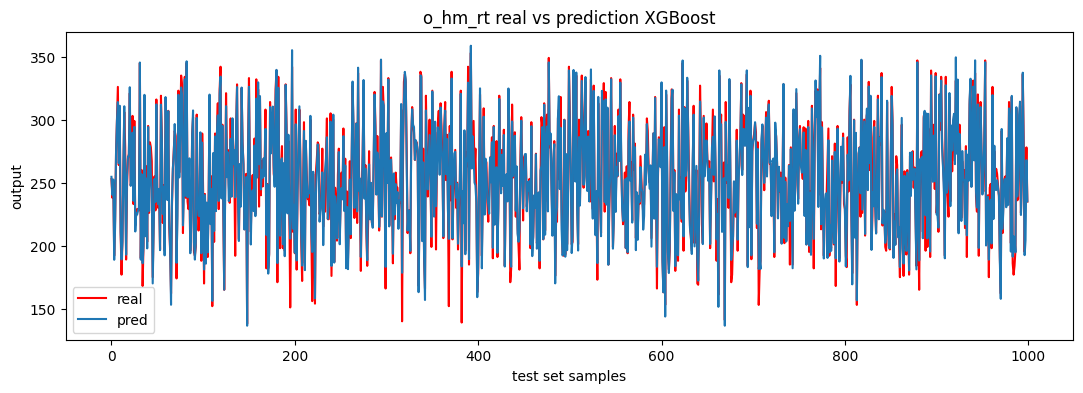

/Users/user/Desktop/CIVS_last_Phase/Forward/2025september/New5000SamplesDataset/PDFshapingUtils.py:353: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(error, bins=n_bins, color="blue")


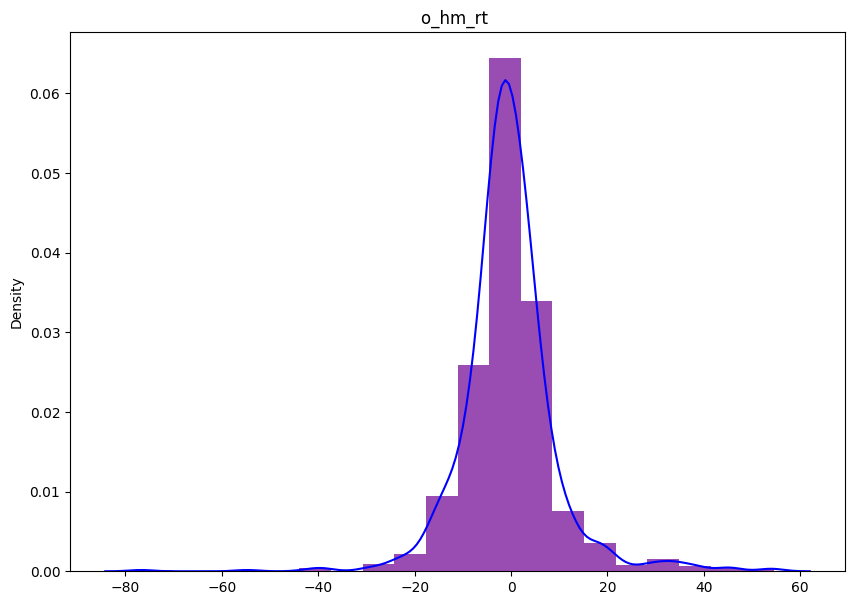

In [60]:

PDFshapingOBJ.plot_preds_vs_reals( list_preds, list_reals )


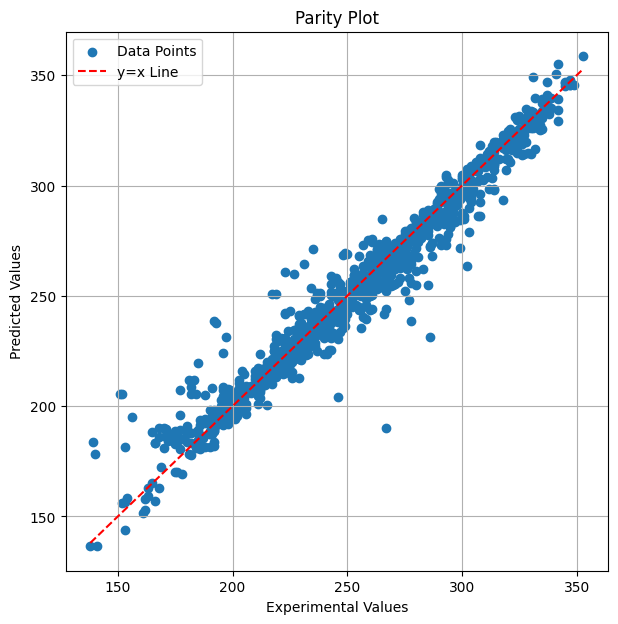

In [61]:

import matplotlib.pyplot as plt
import numpy as np

# Example data: Replace with your actual experimental and predicted values
## experimental_values = np.array([10, 20, 30, 40, 50])
## predicted_values    = np.array([11, 19, 32, 38, 51])

experimental_values = list_reals
predicted_values    = list_preds



plt.figure(figsize=(7, 7)) # Adjust figure size as needed
plt.scatter(experimental_values, predicted_values, label='Data Points')
plt.plot([min(experimental_values), max(experimental_values)],
        [min(experimental_values), max(experimental_values)],
        '--r', label='y=x Line') # Red dashed line for y=x

plt.xlabel('Experimental Values')
plt.ylabel('Predicted Values')
plt.title('Parity Plot')
plt.legend()
plt.grid(True)
plt.show()




## ONNX and XGboost


In [62]:

model = xgb.XGBRegressor(
    n_estimators=100,
    reg_lambda=1,
    gamma=0,
    max_depth=3
)


In [63]:


print(model)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, gamma=0, gpu_id=None,
             grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, predictor=None, random_state=None,
             reg_alpha=None, reg_lambda=1, ...)


In [64]:

model.fit( PDFshapingOBJ.X_train, PDFshapingOBJ.y_train)


XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, gamma=0, gpu_id=-1, grow_policy='depthwise',
             importance_type=None, interaction_constraints='',
             learning_rate=0.300000012, max_bin=256, max_cat_to_onehot=4,
             max_delta_step=0, max_depth=3, max_leaves=0, min_child_weight=1,
             missing=nan, monotone_constraints='()', n_estimators=100, n_jobs=0,
             num_parallel_tree=1, predictor='auto', random_state=0, reg_alpha=0,
             reg_lambda=1, ...)

In [65]:

y_pred = model.predict(PDFshapingOBJ.X_test )


In [66]:

y_pred


array([254.6312 , 240.352  , 252.48323, 188.80508, 215.3097 , 273.73776,
       299.13422, 313.98022, 265.45795, 311.03143, 211.19794, 189.07162,
       202.84085, 262.23154, 310.6263 , 238.5271 , 192.83824, 255.19145,
       270.6559 , 271.56848, 325.7217 , 247.46495, 253.37341, 289.62183,
       235.64867, 294.26257, 211.2628 , 225.95226, 224.64386, 227.77524,
       230.2791 , 345.3379 , 188.94086, 256.55017, 186.06657, 199.20695,
       319.6942 , 207.45718, 253.21301, 197.83485, 294.13684, 227.61064,
       279.0113 , 255.71068, 244.1371 , 170.03348, 210.11531, 252.92325,
       234.6357 , 312.10934, 238.49602, 232.90073, 245.10435, 196.44745,
       311.92032, 283.52985, 225.14967, 246.74434, 192.30942, 317.91315,
       279.45087, 236.19363, 306.7869 , 220.04034, 197.98778, 153.10458,
       235.02927, 261.3078 , 272.85638, 296.51028, 274.07925, 186.40843,
       223.48936, 319.72888, 254.15842, 286.99985, 325.56372, 319.6927 ,
       216.1148 , 241.76   , 332.00833, 239.575  , 

In [67]:

r2_score( PDFshapingOBJ.y_test, y_pred )


0.9524536643872893

In [68]:

initial_types = [(
         'float_input', 
         FloatTensorType(     [ None, PDFshapingOBJ.X.shape[1] ]       )
)]


In [69]:

onnx_name_to_use = 'ONNXmodels/xgboost_' + ONNX_name + '_ort.onnx'

## target_opset=7

onnx_model = onnxmltools.convert_xgboost(model, initial_types=initial_types)

onnxmltools.utils.save_model(onnx_model, onnx_name_to_use)


In [70]:

onnx_name_to_use = 'ONNXmodels/xgboost_' + ONNX_name + '_ort.onnx'

# Setup runtime. This instantiates an ONNX inference session and loads the persisted model.
sess = rt.InferenceSession( onnx_name_to_use )


In [71]:

# Get model metadata to enable mapping of new input to the runtime model
input_name = sess.get_inputs()[0].name
label_name = sess.get_outputs()[0].name


In [72]:

input_name 


'float_input'

In [73]:

label_name


'variable'

In [74]:

# Create predictions. The inputs are the xtest values, and they are being casted as type float32.
pred_onnx = sess.run([label_name], {input_name: PDFshapingOBJ.X_test.astype(np.float32)})[0]


In [75]:

# Print first 10 predictions
print("Prediction:\n", pred_onnx[0:10])


Prediction:
 [[254.63116]
 [240.35199]
 [252.48322]
 [188.80507]
 [215.30965]
 [273.7378 ]
 [299.13428]
 [313.98013]
 [265.45786]
 [311.03156]]


In [76]:

test_count = 10
test_cases = PDFshapingOBJ.X_test[0:test_count]
local_pred = model.predict(test_cases)
print(f"Local predictions are: {local_pred}")


Local predictions are: [254.6312  240.352   252.48323 188.80508 215.3097  273.73776 299.13422
 313.98022 265.45795 311.03143]


In [77]:

test_cases


array([[   0. ,  120. ,    0. ,   30. ,   24. ,  300. ,    0. , 1480. ,
         195. ,    5.7,    3. ,    0. ,    0. ,    0. ],
       [  50. ,    0. ,    0. ,    0. ,   27. ,    0. , 1200. , 1480. ,
         160. ,    5.7,    7. ,    0. ,    0. ,    0. ],
       [  10. ,    0. ,    0. ,    0. ,   21. ,    0. , 1200. , 1200. ,
         230. ,    5.7,    3. ,    0. ,    0. ,    0. ],
       [   0. ,    0. ,    0. ,   41. ,   30. ,  300. ,    0. , 1480. ,
         160. ,    5.7,    5. ,    0. ,    0. ,    0. ],
       [   0. ,   41. ,    0. ,    0. ,   24. ,    0. ,    0. , 1200. ,
         195. ,    5.7,    1. ,    0. ,    0. ,    0. ],
       [  10. ,    0. ,    0. ,    0. ,   27. ,    0. ,  300. , 1600. ,
         230. ,    5.7,    5. ,    0. ,    0. ,    0. ],
       [  30. ,    0. ,    0. ,    0. ,   27. ,    0. , 1200. , 1480. ,
         230. ,    5.7,    7. ,    0. ,    0. ,    0. ],
       [  20. ,    0. ,    0. ,   90. ,   21. ,  300. ,  300. , 1480. ,
         230. ,    5.7,  


## ONNX, XGBoost, and SKlearn pipeline


In [78]:

update_registered_converter(
    XGBRegressor, 'XGBoostXGBRegressor',
    calculate_linear_regressor_output_shapes, 
    convert_xgboost
)


In [79]:

model = xgb.XGBRegressor(
    n_estimators=100,
    reg_lambda=1,
    gamma=0,
    max_depth=3
)

pipe = Pipeline([
            ('xgb', model) 
])



pipe.fit( PDFshapingOBJ.X_train, PDFshapingOBJ.y_train)


Pipeline(steps=[('xgb',
                 XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
                              colsample_bylevel=1, colsample_bynode=1,
                              colsample_bytree=1, early_stopping_rounds=None,
                              enable_categorical=False, eval_metric=None,
                              gamma=0, gpu_id=-1, grow_policy='depthwise',
                              importance_type=None, interaction_constraints='',
                              learning_rate=0.300000012, max_bin=256,
                              max_cat_to_onehot=4, max_delta_step=0,
                              max_depth=3, max_leaves=0, min_child_weight=1,
                              missing=nan, monotone_constraints='()',
                              n_estimators=100, n_jobs=0, num_parallel_tree=1,
                              predictor='auto', random_state=0, reg_alpha=0,
                              reg_lambda=1, ...))])

In [80]:

y_pred = pipe.predict(PDFshapingOBJ.X_test )


In [81]:

y_pred


array([254.6312 , 240.352  , 252.48323, 188.80508, 215.3097 , 273.73776,
       299.13422, 313.98022, 265.45795, 311.03143, 211.19794, 189.07162,
       202.84085, 262.23154, 310.6263 , 238.5271 , 192.83824, 255.19145,
       270.6559 , 271.56848, 325.7217 , 247.46495, 253.37341, 289.62183,
       235.64867, 294.26257, 211.2628 , 225.95226, 224.64386, 227.77524,
       230.2791 , 345.3379 , 188.94086, 256.55017, 186.06657, 199.20695,
       319.6942 , 207.45718, 253.21301, 197.83485, 294.13684, 227.61064,
       279.0113 , 255.71068, 244.1371 , 170.03348, 210.11531, 252.92325,
       234.6357 , 312.10934, 238.49602, 232.90073, 245.10435, 196.44745,
       311.92032, 283.52985, 225.14967, 246.74434, 192.30942, 317.91315,
       279.45087, 236.19363, 306.7869 , 220.04034, 197.98778, 153.10458,
       235.02927, 261.3078 , 272.85638, 296.51028, 274.07925, 186.40843,
       223.48936, 319.72888, 254.15842, 286.99985, 325.56372, 319.6927 ,
       216.1148 , 241.76   , 332.00833, 239.575  , 

In [82]:

r2_score( PDFshapingOBJ.y_test, y_pred )


0.9524536643872893

In [83]:

onnx_name_to_use = 'pipeline_xgboost_' + ONNX_name

model_onnx = convert_sklearn(
    pipe, 
    onnx_name_to_use,
    [ ('input', FloatTensorType([None, PDFshapingOBJ.X.shape[1]])) ],
    target_opset={'': 7, 'ai.onnx.ml': 1})


In [84]:

onnx_name_to_use = "ONNXmodels/pipeline_xgboost_" + ONNX_name + ".onnx"

with open(onnx_name_to_use, "wb") as f:
    f.write(model_onnx.SerializeToString())
    

In [85]:
onx = to_onnx(pipe, PDFshapingOBJ.X_test.astype(np.float32),
              target_opset={'': 7, 'ai.onnx.ml': 1})

sess = rt.InferenceSession(onx.SerializeToString())
pred_onx = sess.run(None, {"X": PDFshapingOBJ.X_test[:5].astype(np.float32)})
print("predict", pred_onx[0].ravel())



predict [254.6312  240.352   252.48323 188.80508 215.3097 ]


In [86]:

input_name = sess.get_inputs()[0].name
label_name = sess.get_outputs()[0].name


In [87]:
label_name 

'variable'

In [88]:
input_name 

'X'